In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
df_A = pd.read_csv('/content/dataset_A_machine_temperature_defects.csv')
df_B = pd.read_csv('/content/dataset_B_machine_sensors.csv')
df_C = pd.read_csv('/content/dataset_C_hourly_production.csv')

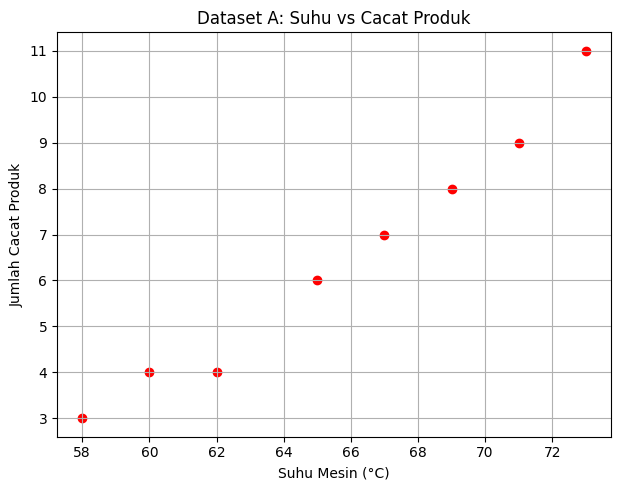

In [ ]:
# Dataset A: Scatter Plot Suhu vs Cacat
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_A['Temperature_C'], df_A['Defective_Products'], color='red')
plt.title('Dataset A: Suhu vs Cacat Produk')
plt.xlabel('Suhu Mesin (°C)')
plt.ylabel('Jumlah Cacat Produk')
plt.grid(True)
plt.tight_layout()
plt.show()

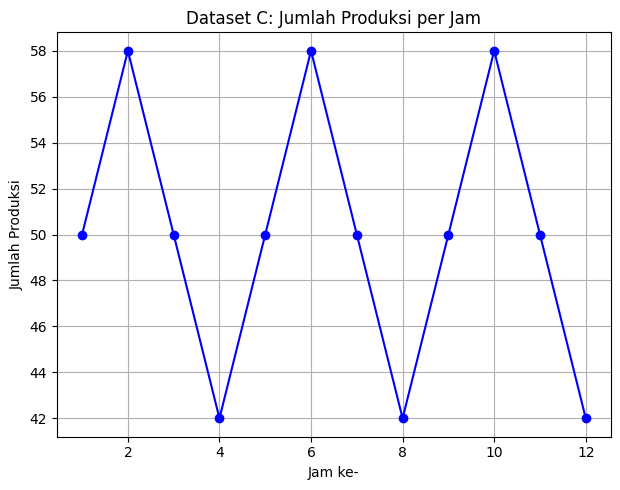

In [ ]:
# Dataset C: Line Chart Produksi per Jam
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(df_C['Hour'], df_C['Production'], marker='o', linestyle='-', color='blue')
plt.title('Dataset C: Jumlah Produksi per Jam')
plt.xlabel('Jam ke-')
plt.ylabel('Jumlah Produksi')
plt.grid(True)
plt.tight_layout()
plt.show()

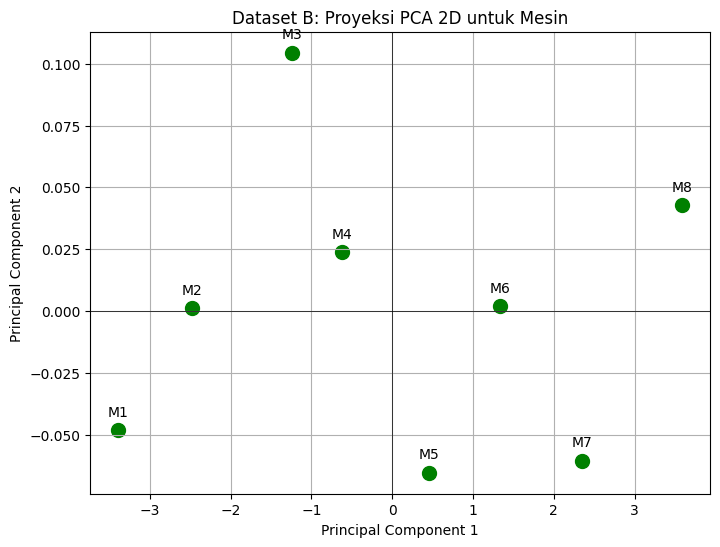

In [ ]:
# Memilih fitur numerik untuk PCA
features = ['Vibration', 'Temperature', 'Current', 'Pressure', 'Noise']
x = df_B[features].values

# Standarisasi data
x = StandardScaler().fit_transform(x)

# Mengaplikasikan PCA untuk reduksi ke 2 dimensi
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
df_pca = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
df_pca['Machine'] = df_B['Machine']

# Visualisasi Hasil Proyeksi PCA ke 2D
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], color='green', s=100)

# Menambahkan label nama mesin pada tiap titik
for i, txt in enumerate(df_pca['Machine']):
    plt.annotate(txt, (df_pca['PC1'][i], df_pca['PC2'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Dataset B: Proyeksi PCA 2D untuk Mesin')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.show()